# 3_pitchfork_test

Testing results from single pitchfork

In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product
from scipy import constants
from scipy import stats
import random
import astropy.constants
from numpy.random import default_rng

#### graphical
import matplotlib.pyplot as plt

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers

#### custom
from InversePCA import InversePCA
from WMSE import WMSE, WMSE_metric

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="1"

physical_devices = tf.config.list_physical_devices("GPU") 

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

2024-03-06 11:02:35.460630: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-06 11:02:35.460660: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-06 11:02:35.461509: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-06 11:02:35.466175: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-03-06 11:02:36.017060: W tensorflow/compiler/tf2

Current GPU usage:
 - GPU0: 0B



2024-03-06 11:02:36.524971: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18447 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:61:00.0, compute capability: 8.6


## 1) load in grid
keep same routine as during training

In [2]:
df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/barbie_nu.h5', key='df')

#### define inputs
inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

#### define outputs
classical_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std']
astero_outputs = [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = classical_outputs+astero_outputs

#### train/test split
seed = 42

df_train = df_full.sample(frac=0.95, random_state=seed)
df_test = df_full.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.005, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Testing set: ", len(df_test))
print("Validation set: ", len(df_val_inputs))

#### can't have too many describes
df_full.describe()

Training set:  1097323
Testing set:  58044
Validation set:  5515


,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,surface_Z,nu_max,...,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std,log_nu_0_41_std,log_nu_0_42_std,log_nu_0_43_std,log_nu_0_44_std,log_nu_0_45_std
count,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,...,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06
mean,1.018413e+00,1.576475e-02,2.782837e-01,1.800447e+00,4.628984e+00,1.132672e+00,1.811612e+00,6.040085e+03,1.364829e-02,2.695808e+03,...,6.778618e-15,-2.855876e-15,1.653083e-15,4.966201e-15,7.047146e-16,7.653635e-15,-2.083393e-15,4.996951e-15,2.264860e-15,-4.464009e-15
std,1.188714e-01,1.314553e-02,2.294834e-02,1.153523e-01,3.492387e+00,2.576956e-01,1.362638e+00,6.644132e+02,1.252237e-02,9.594349e+02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,7.000000e-01,1.241437e-03,2.400195e-01,1.600098e+00,1.865560e-02,6.006561e-01,2.575467e-01,4.663410e+03,9.960149e-05,7.069718e+02,...,-3.256371e+00,-3.256499e+00,-3.256724e+00,-3.256984e+00,-3.257242e+00,-3.257479e+00,-3.257698e+00,-3.257904e+00,-3.258101e+00,-3.258289e+00
25%,9.330000e-01,4.428834e-03,2.583105e-01,1.700684e+00,1.798067e+00,9.507823e-01,8.449202e-01,5.545393e+03,2.653046e-03,1.978679e+03,...,-6.128663e-01,-6.127785e-01,-6.126330e-01,-6.124484e-01,-6.122666e-01,-6.121199e-01,-6.119341e-01,-6.117809e-01,-6.116612e-01,-6.114950e-01
50%,1.035000e+00,1.159459e-02,2.773438e-01,1.800146e+00,3.836663e+00,1.088573e+00,1.414103e+00,5.952699e+03,9.949250e-03,2.654218e+03,...,1.245599e-01,1.246725e-01,1.248018e-01,1.249217e-01,1.250079e-01,1.250797e-01,1.251489e-01,1.252120e-01,1.252990e-01,1.254035e-01
75%,1.116000e+00,2.475267e-02,2.978125e-01,1.900488e+00,6.870449e+00,1.264503e+00,2.353924e+00,6.415778e+03,2.235996e-02,3.367139e+03,...,7.340587e-01,7.339929e-01,7.338441e-01,7.337370e-01,7.336355e-01,7.335394e-01,7.334309e-01,7.333475e-01,7.332500e-01,7.331606e-01
max,1.200000e+00,5.053113e-02,3.199902e-01,1.999951e+00,1.399994e+01,2.117572e+00,1.547402e+01,8.882541e+03,5.051477e-02,6.181659e+03,...,2.499163e+00,2.499528e+00,2.499303e+00,2.499460e+00,2.499623e+00,2.499766e+00,2.499893e+00,2.500011e+00,2.500124e+00,2.500231e+00


In [3]:
"""
pca
"""
#### define pca global vars
n_components = 5
seed = 42

#### define and fit pca
pca = PCA(n_components=n_components, random_state=seed)
pca.fit(df_full[astero_outputs])

#### print variance with chosen n_comps
print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))

Explained variance ratio with n_comps = 5 is 0.9999999738098696


In [4]:
"""
DEFINE WEIGHTS FOR WMSE
"""
log_weights = (1/np.log(10)) * np.array([0.01, 0.02, 0.0001,0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1] / df_full[["radius", "luminosity", "surface_Z"] + [f'nu_0_{i+1}' for i in range(14,25)]].mean())

log_weights = log_weights / df_full[["log_radius", "log_luminosity", "log_surface_Z"] + [f'log_nu_0_{i+1}' for i in range(14,25)]].std()


weights = log_weights.values.tolist()

print(weights)

[0.0404396032697295, 0.01593228797007494, 0.004452107630433814, 0.00016667030242831007, 0.00015733933591581152, 0.0001491147982946965, 0.00014175098532282846, 0.00013505912143240066, 0.000128934434739406, 0.0001233175056851056, 0.00011815420774364464, 0.00011339103527327905, 0.00010897713404833435, 0.00010486947466103136]


In [5]:
def calc_Teff(luminosity, radius):
    return np.array(((luminosity.values*astropy.constants.L_sun) / (4*np.pi*constants.sigma*((radius.values*astropy.constants.R_sun)**2)))**0.25)

def rescale_preds(preds, df, column):
    if 'star_feh' in column:
        return (preds[column+"_std"]*df[column].std())+df[column].mean()
    else:
        return 10**((preds["log_"+column+"_std"]*df["log_"+column].std())+df["log_"+column].mean())

## Testing results from pitchfork


In [6]:
"""
load in angry mob
"""
pca_comps = pca.components_
pca_mean = pca.mean_

custom_objects = {"InversePCA": InversePCA(pca_comps, pca_mean),"WMSE": WMSE(weights)}

pitchfork_name = "stem_2_256_ctine_2_64_atine_12_128_WMSE_65536batch_exp2e4_50kepochs_swish"
pitchfork = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/models/barbie/" + pitchfork_name + ".h5", custom_objects=custom_objects)


In [7]:

inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

pred_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std'] + [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = ['radius', 'luminosity', 'surface_Z'] + [f'nu_0_{i+1}' for i in range(14,25)]

preds = pitchfork(np.array(df_test[inputs]))

preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)


for output in outputs:
    preds_df[output] = rescale_preds(preds_df, df_full, output)

preds_df['effective_T'] = calc_Teff(preds_df["luminosity"],preds_df["radius"])

pitchfork_errors_df=pd.DataFrame(np.array(df_test[outputs+['effective_T']]) - np.array(preds_df[outputs+['effective_T']]), columns=[outputs+['effective_T']])

2024-03-06 11:02:55.191403: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-03-06 11:02:55.248173: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904


In [8]:
pitchfork_errors_df

,radius,luminosity,surface_Z,nu_0_15,nu_0_16,nu_0_17,nu_0_18,nu_0_19,nu_0_20,nu_0_21,nu_0_22,nu_0_23,nu_0_24,nu_0_25,effective_T
0,0.000215,0.001404,2.578504e-06,0.284858,0.455100,0.601761,0.500425,0.634734,0.569220,0.819486,0.767784,0.811803,0.776482,0.737293,9.463592
1,0.000009,0.002088,-7.199822e-06,0.101238,0.417816,0.497584,0.271411,0.420395,0.409522,0.750297,0.714921,0.741810,0.703109,0.660831,11.190441
2,-0.000240,0.000787,-3.057527e-06,-0.275714,0.091709,0.160830,-0.138948,0.009967,-0.043085,0.207352,0.110898,0.098829,0.120794,0.147980,9.901117
3,-0.000195,0.000502,-1.647963e-07,-0.219228,0.141091,0.174781,-0.150691,0.006434,-0.021592,0.234700,0.134818,0.108310,0.116041,0.139639,9.325267
4,-0.000055,0.000129,4.175693e-06,-0.058865,0.269734,0.245864,-0.097158,0.088550,0.102938,0.367650,0.263742,0.224793,0.231372,0.259581,8.322859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58039,0.001409,0.001163,-6.845714e-06,-0.544251,-0.484847,-0.829076,-1.033622,-0.854307,-0.668319,-0.632953,-0.783177,-0.909369,-0.899098,-0.727816,5.331840
58040,0.001635,0.001845,-8.165228e-06,-0.283640,-0.181416,-0.459533,-0.579334,-0.384669,-0.191651,-0.161014,-0.270121,-0.376983,-0.342205,-0.198530,5.298090
58041,0.002682,0.006016,-1.321107e-05,-0.079664,-0.177571,-0.288867,-0.236767,-0.107236,-0.107629,-0.209209,-0.306646,-0.351166,-0.302792,-0.236790,5.697963
58042,0.002775,0.004437,-9.309967e-06,-0.019047,-0.635508,-0.457332,-0.350872,-0.220097,-0.487720,-0.528687,-0.657711,-0.559145,-0.673816,-0.642103,4.424608


In [1]:
def output_plot(output, target_unc, axis):
    errors = pitchfork_errors_df[output]
    errors_mad = stats.median_abs_deviation(errors)
    errors_med = np.median(errors)
    
    axis.hist(errors, bins=1000)
    axis.axvline(target_unc, linestyle='dashed', color='black')
    axis.axvline(-target_unc, linestyle='dashed', color='black')
    axis.axvline(0, color='black')
    axis.axvline(errors_med + errors_mad, color='orange')
    axis.axvline(errors_med -errors_mad, color='orange')
    axis.set_xlim(-5*errors_mad, 5*errors_mad)
    axis.set_title(output)
    axis.set_yticks([])

def pitchfork_eval(pitchfork, df_test):
    inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

    pred_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std'] + [f'log_nu_0_{i+1}_std' for i in range(14,25)]
    
    outputs = ['radius', 'luminosity', 'surface_Z'] + [f'nu_0_{i+1}' for i in range(14,25)]
    
    preds = pitchfork(np.array(df_test[inputs]))
    
    preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)
    
    for output in outputs:
        preds_df[output] = rescale_preds(preds_df, df_full, output)
    
    preds_df['effective_T'] = calc_Teff(preds_df["luminosity"],preds_df["radius"])
    
    pitchfork_errors_df=pd.DataFrame(np.array(df_test[outputs+['effective_T']]) - np.array(preds_df[outputs+['effective_T']]), columns=[outputs+['effective_T']])

    fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(20,10))

    output_plot('radius', 0.01, ax1)

    output_plot('luminosity', 0.02, ax2)
    
    output_plot('effective_T', 5, ax3)

    output_plot('surface_Z', 0.0001, ax4)

    output_plot('nu_0_15', 0.2, ax5)

    output_plot('nu_0_18', 0.2, ax6)

    output_plot('nu_0_21', 0.2, ax7)

    output_plot('nu_0_24', 0.2, ax8)

In [2]:
pitchfork_eval(pitchfork, df_test)

NameError: name 'pitchfork' is not defined

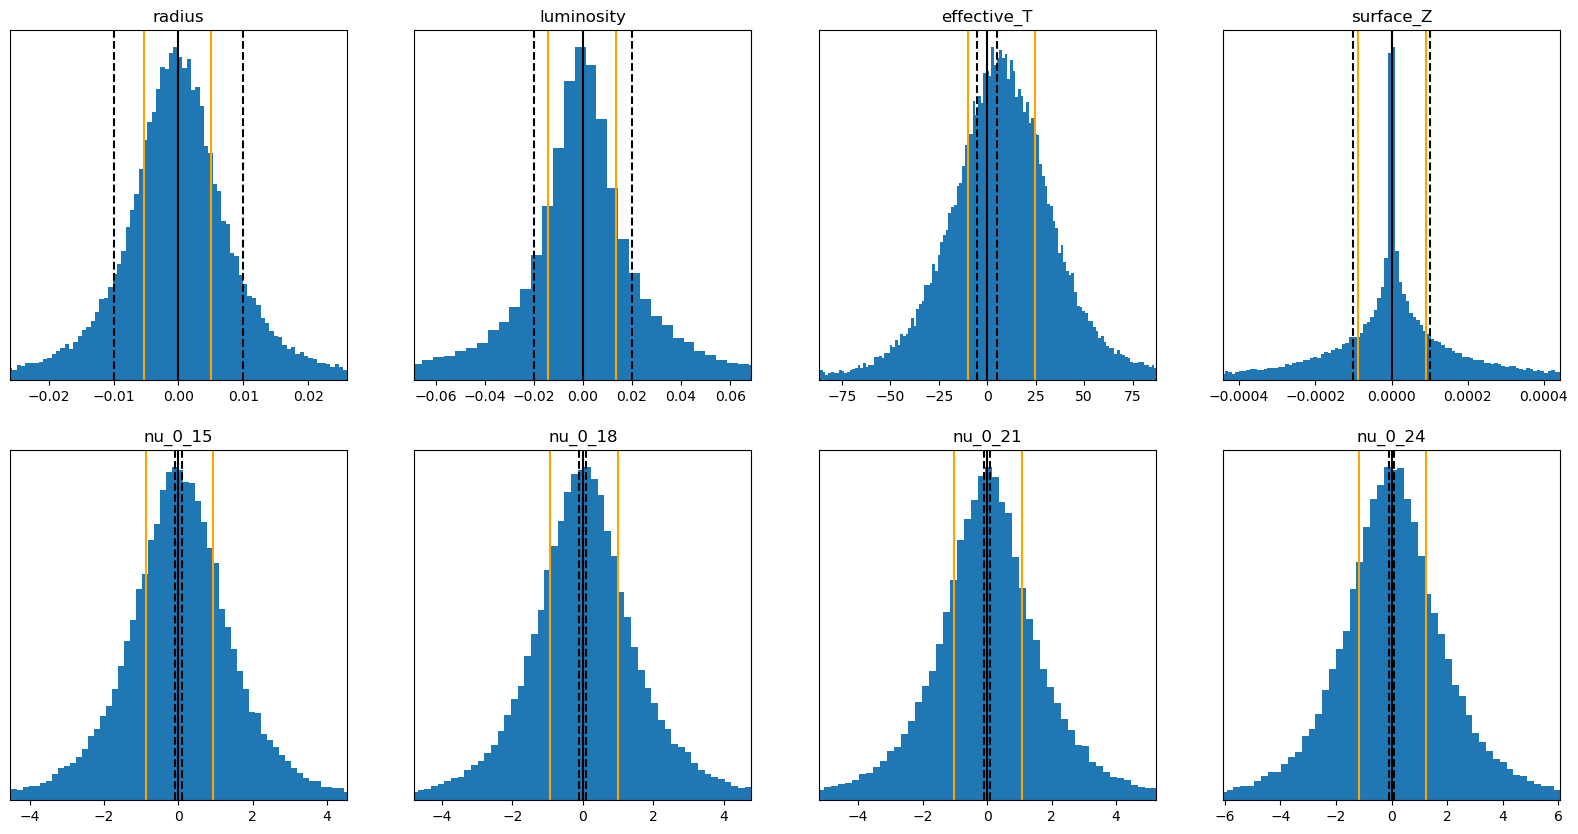

In [20]:
pitchfork_eval(pitchfork, df_test)

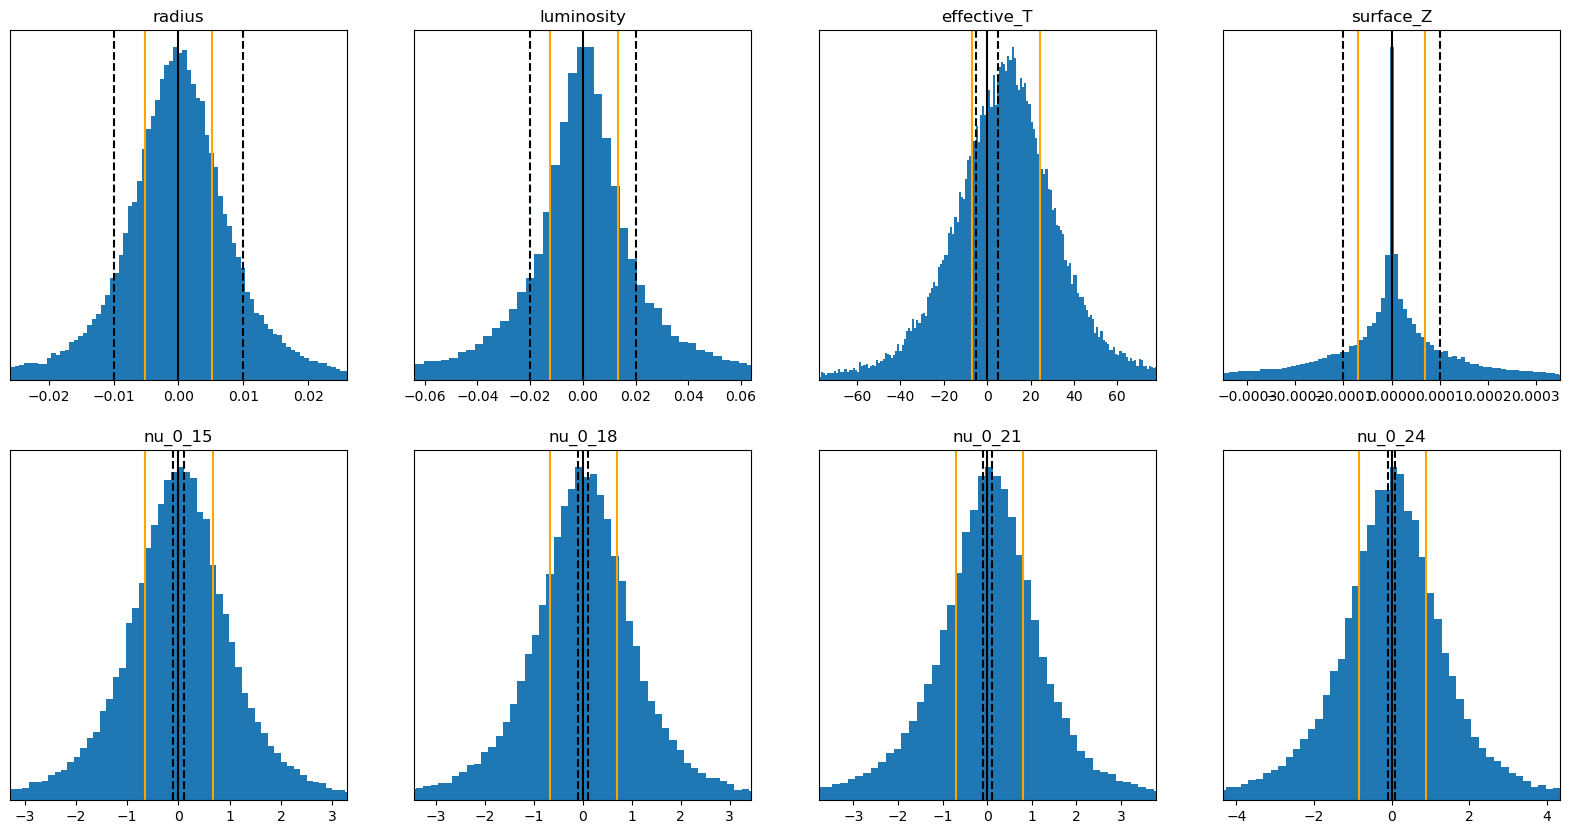

In [29]:
pitchfork_eval(pitchfork, df_test)

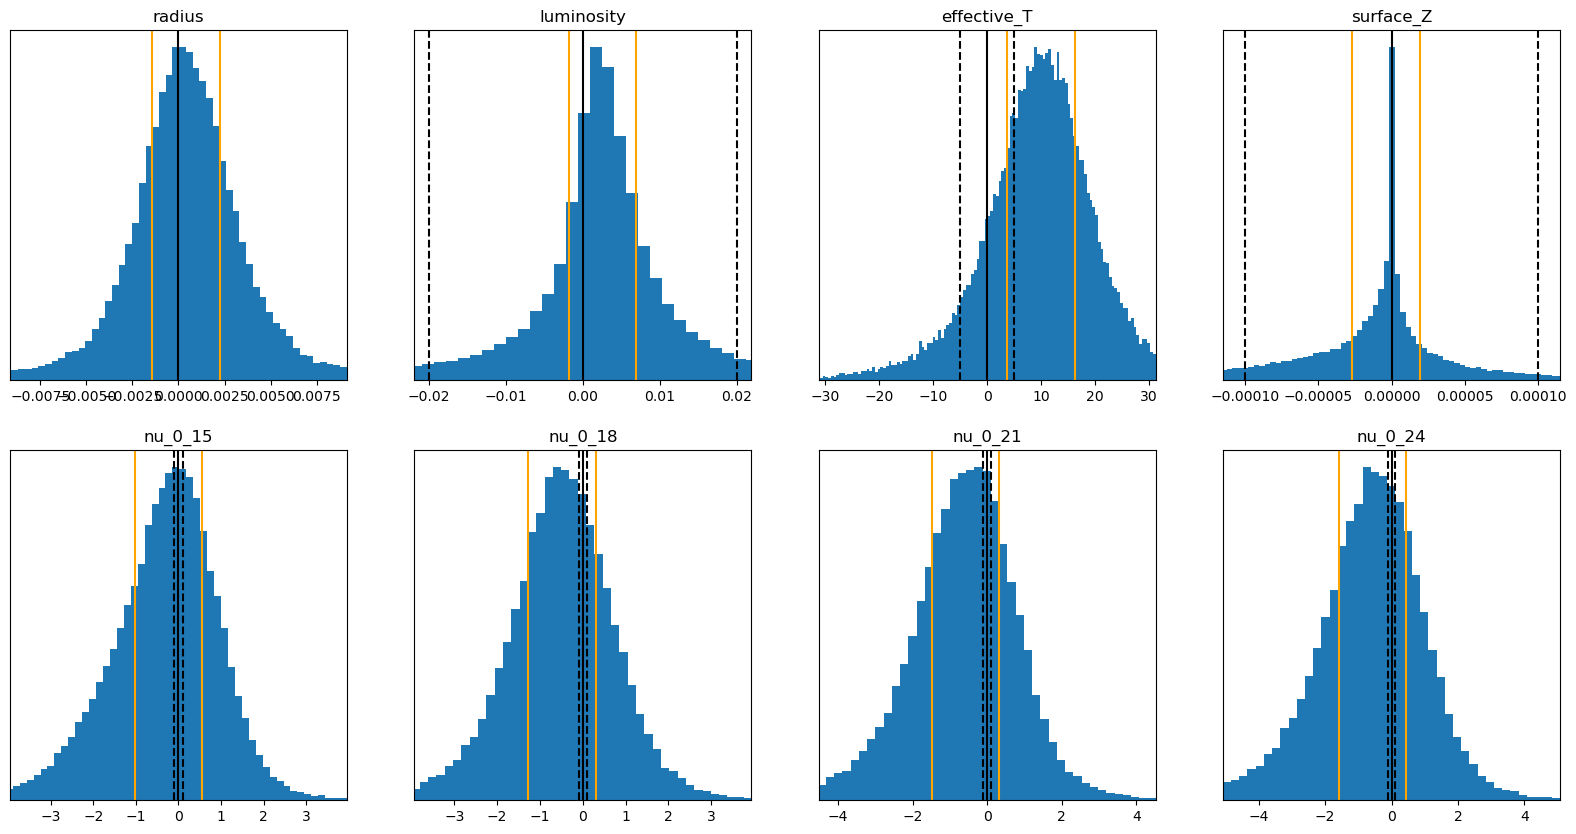

In [38]:
pitchfork_eval(pitchfork, df_test)

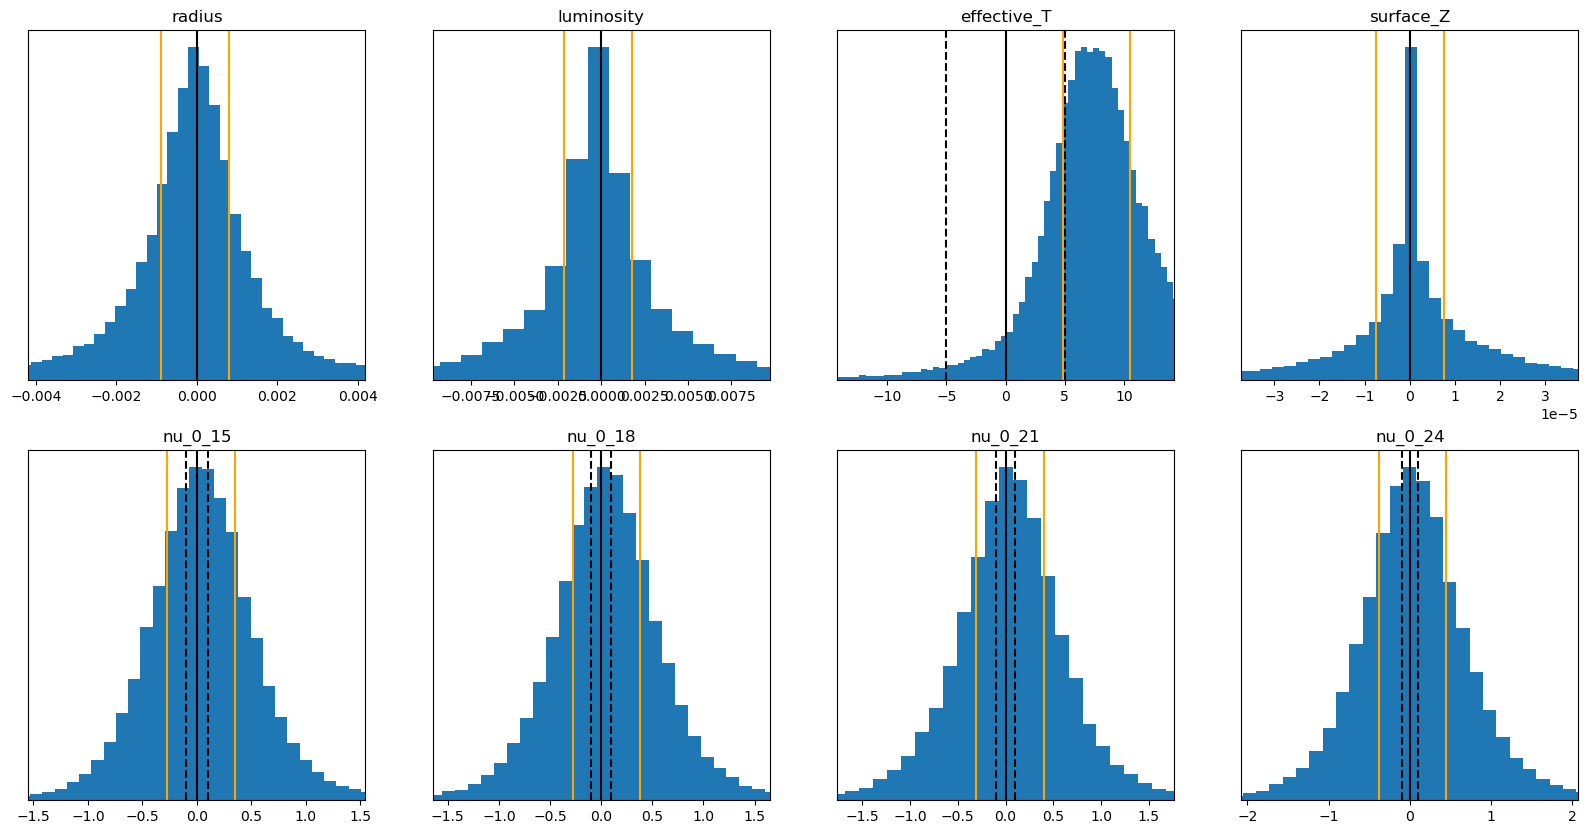

In [43]:
pitchfork_eval(pitchfork, df_test)

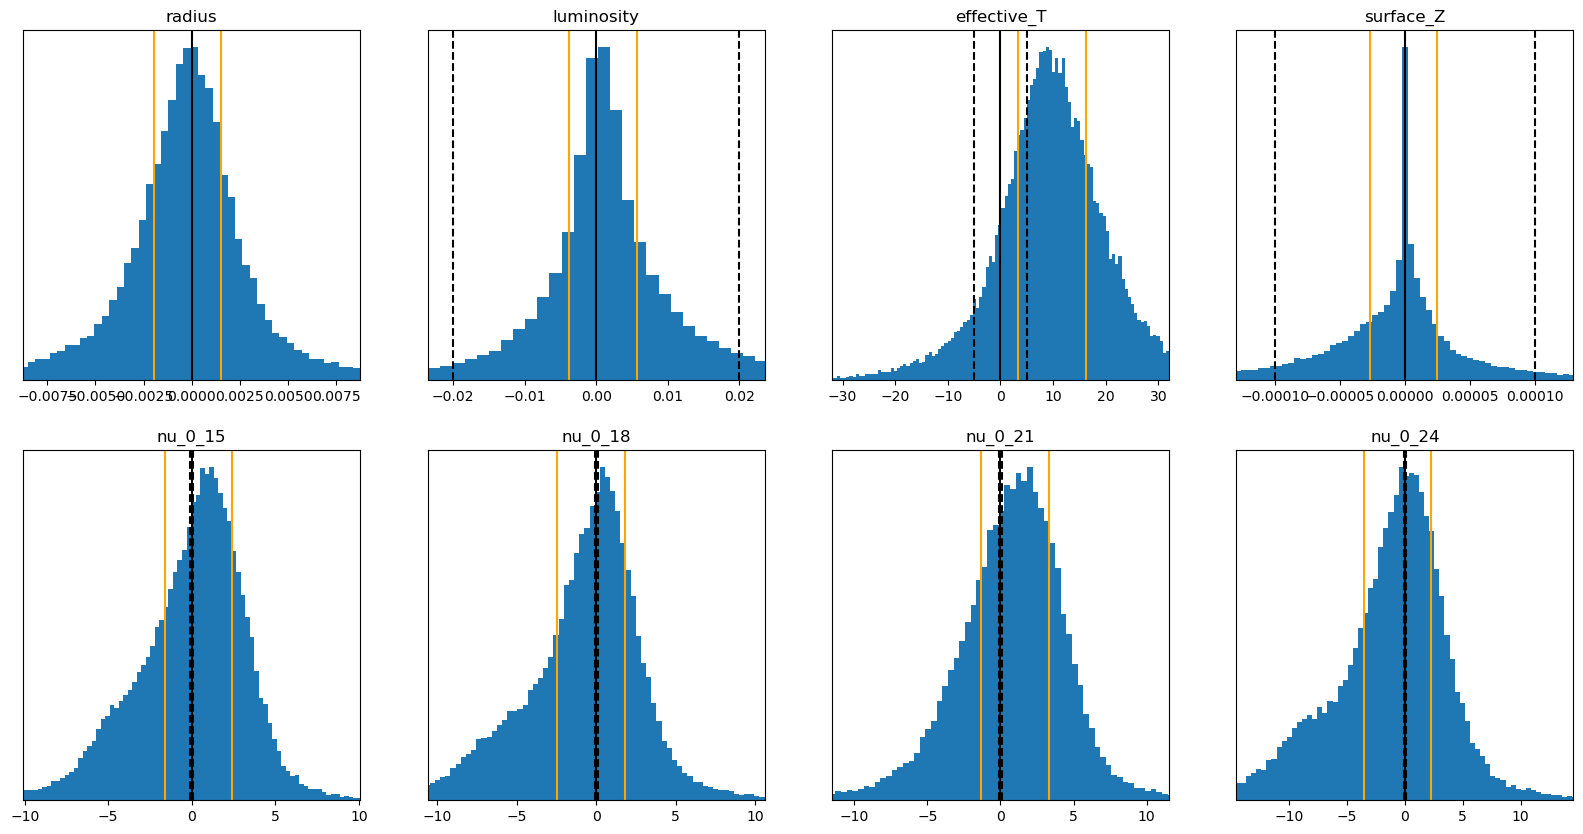

In [48]:
pitchfork_eval(pitchfork, df_test)